In [1]:
# ============================================================
# 1. IMPORT
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve
)

from xgboost import XGBClassifier

RANDOM_STATE = 42


In [2]:
from pathlib import Path
DATA_DIR = Path("../../data/gold").resolve()
PD_PATH = DATA_DIR / "abt_ews.parquet"

df = pd.read_parquet(PD_PATH)

# Rapikan nama kolom
df.columns = df.columns.str.strip()

# Konversi tipe setelah membaca Parquet
string_columns = [
    "facility_id",
    "cif_sk",
    "grup_id",
    "split",
    "y_default_6bln",
]

for col in string_columns:
    if col in df.columns:
        df[col] = df[col].astype("string")
        
# Normalisasi split
df["split"] = (
    df["split"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# Normalisasi target:
# menangani "0"/"1", 0/1, \N, kosong, NaN secara konsisten
# ------------------------------------------------------------
target_raw = (
    df["y_default_6bln"]
    .astype("string")
    .str.strip()
)

target_raw = target_raw.replace({
    r"\N": pd.NA,
    "": pd.NA,
    "nan": pd.NA,
    "NaN": pd.NA,
    "None": pd.NA,
    "<NA>": pd.NA
})

df["y_default_6bln"] = (
    pd.to_numeric(target_raw, errors="coerce")
    .astype("Int64")
)

# Parse tanggal secara aman
df["snapshot_date"] = pd.to_datetime(
    df["snapshot_date"],
    errors="coerce"
)

# Pastikan setelah normalisasi hanya ada 0/1/NA
invalid_target = (
    df["y_default_6bln"]
    .dropna()
    .loc[lambda s: ~s.isin([0, 1])]
)

if len(invalid_target) > 0:
    raise ValueError(
        "Ditemukan nilai target selain 0/1 setelah normalisasi: "
        f"{sorted(invalid_target.unique().tolist())}"
    )

print("Shape:", df.shape)
print("Periode:", df["snapshot_date"].min(), "s.d.", df["snapshot_date"].max())

print("\nTarget setelah normalisasi:")
print(df["y_default_6bln"].value_counts(dropna=False))

print("\nSplit setelah normalisasi:")
print(df["split"].value_counts(dropna=False))

display(df.head())

Shape: (126128, 20)
Periode: 2022-01-31 00:00:00 s.d. 2026-12-31 00:00:00

Target setelah normalisasi:
0      103041
NaN     21896
1        1191
Name: y_default_6bln, dtype: Int64

Split setelah normalisasi:
latih      116930
uji_oot      9198
Name: split, dtype: Int64


,facility_id,cif_sk,grup_id,snapshot_date,split,app_rating_internal,app_sektor_kbli,app_skor_kredit,graf_group_exposure_share,perilaku_covenant_dilanggar,perilaku_dpd,perilaku_dpd_maks_3bln,perilaku_kol_maks_3bln,perilaku_kol_memburuk,perilaku_kolektibilitas,perilaku_pemakaian_plafon,perilaku_restrukturisasi,perilaku_umur_fasilitas_hari,y_default_6bln,y_tersensor
0,1,1124,140,2022-02-28,latih,B,G,5.5,0.002007,2,0,0.0,1.0,False,1,0.387701,False,20,0,False
1,1,1124,140,2022-03-31,latih,B,G,5.5,0.002007,2,0,0.0,1.0,False,1,0.387701,False,51,0,False
2,1,1124,140,2022-04-30,latih,B,G,5.5,0.006665,3,0,0.0,1.0,False,1,0.387701,False,81,0,False
3,1,1124,140,2022-05-31,latih,B,G,5.5,0.009715,2,0,0.0,1.0,False,1,0.387701,False,112,0,False
4,1,1124,140,2022-06-30,latih,B,G,5.5,0.009715,3,0,0.0,1.0,False,1,0.387701,False,142,0,False


In [3]:
# ============================================================
# 3. DATA AUDIT
# ============================================================

print("Periode:", df["snapshot_date"].min(), "s.d.", df["snapshot_date"].max())
print("Facility:", df["facility_id"].nunique())
print("CIF:", df["cif_sk"].nunique())
print("Group:", df["grup_id"].nunique())

print("\nSplit:")
print(df["split"].value_counts(dropna=False))

print("\nTarget:")
print(df["y_default_6bln"].value_counts(dropna=False))

print("\nCensoring:")
print(df["y_tersensor"].value_counts(dropna=False))

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": df.isna().mean(),
    "nunique": df.nunique(dropna=True)
})

display(audit)


Periode: 2022-01-31 00:00:00 s.d. 2026-12-31 00:00:00
Facility: 4400
CIF: 4400
Group: 1333

Split:
latih      116930
uji_oot      9198
Name: split, dtype: Int64

Target:
0      103041
NaN     21896
1        1191
Name: y_default_6bln, dtype: Int64

Censoring:
False    104232
True      21896
Name: y_tersensor, dtype: int64


,dtype,missing_n,missing_pct,nunique
facility_id,string,0,0.000000,4400
cif_sk,string,0,0.000000,4400
grup_id,string,0,0.000000,1333
snapshot_date,datetime64[ns],0,0.000000,60
split,string,0,0.000000,2
app_rating_internal,object,0,0.000000,10
app_sektor_kbli,object,0,0.000000,18
app_skor_kredit,float64,0,0.000000,4233
graf_group_exposure_share,float64,0,0.000000,4154
perilaku_covenant_dilanggar,int64,0,0.000000,4


# Kenapa snapshot setelah 30 Juni 2026 dikeluarkan?

Target adalah default dalam **6 bulan ke depan**. Dataset berakhir pada 31 Desember 2026.

Mulai snapshot Juli 2026, obligor yang belum default belum punya outcome 6 bulan penuh sehingga banyak target menjadi `\N`/tersensor. Memasukkan hanya positive yang sudah sempat default tetapi membuang negative yang belum observable akan menyebabkan **selection bias**.

Untuk fixed-horizon binary classification yang clean, notebook ini menggunakan snapshot sampai **30 Juni 2026**.


In [4]:
# ============================================================
# 4. TARGET CLEANING + FIXED-HORIZON CUTOFF
# ============================================================

OUTCOME_CUTOFF = pd.Timestamp("2026-06-30")

# Setelah normalisasi, observasi yang tersensor menjadi NA.
# Jadi cukup gunakan target yang tidak NA.
model_base = df[
    (df["snapshot_date"] <= OUTCOME_CUTOFF)
    & (df["y_default_6bln"].notna())
].copy()

model_base["y"] = model_base["y_default_6bln"].astype("int8")

train_base = model_base[
    model_base["split"].eq("latih")
].copy()

oot_base = model_base[
    model_base["split"].eq("uji_oot")
].copy()


def target_summary(d, name):
    print(
        name,
        "| rows =", len(d),
        "| default =", int(d["y"].sum()) if len(d) else 0,
        "| default rate =", round(float(d["y"].mean()), 6) if len(d) else np.nan,
        "| facilities =", d["facility_id"].nunique()
    )


target_summary(train_base, "TRAIN")
target_summary(oot_base, "OOT")

# Fail-fast agar masalah filtering ketahuan sebelum Cross Validation
if len(train_base) == 0:
    raise ValueError(
        "TRAIN kosong setelah filtering. "
        "Cek output Cell 2-4: split, snapshot_date, dan y_default_6bln."
    )

if train_base["y"].nunique() < 2:
    raise ValueError(
        "TRAIN hanya memiliki satu kelas target. "
        "Binary classification membutuhkan kelas 0 dan 1."
    )

if len(oot_base) == 0:
    raise ValueError(
        "OOT kosong setelah filtering. "
        "Cek split == 'uji_oot' dan cutoff tanggal."
    )

overlap_facility = (
    set(train_base["facility_id"])
    & set(oot_base["facility_id"])
)

print("Facility overlap train vs OOT:", len(overlap_facility))


TRAIN | rows = 98999 | default = 1040 | default rate = 0.010505 | facilities = 3711
OOT | rows = 5158 | default = 76 | default rate = 0.014734 | facilities = 689
Facility overlap train vs OOT: 0


In [5]:
# ============================================================
# 5. FEATURE ENGINEERING - HANYA CURRENT / PAST INFORMATION
# ============================================================

def build_features(raw_df):
    x = raw_df.sort_values(["facility_id", "snapshot_date"]).copy()

    rating_order = {
        "AAA": 1, "AA": 2, "A": 3, "BBB": 4, "BB": 5,
        "B": 6, "CCC": 7, "CC": 8, "C": 9, "D": 10
    }

    x["app_rating_ord"] = (
        x["app_rating_internal"]
        .map(rating_order)
        .astype(float)
    )

    x["dpd_gap_vs_max3m"] = (
        x["perilaku_dpd_maks_3bln"]
        - x["perilaku_dpd"]
    )

    x["kol_gap_vs_max3m"] = (
        x["perilaku_kol_maks_3bln"]
        - x["perilaku_kolektibilitas"]
    )

    lag_map = {
        "perilaku_dpd": "dpd",
        "perilaku_pemakaian_plafon": "util",
        "perilaku_covenant_dilanggar": "covenant",
        "perilaku_kolektibilitas": "kol"
    }

    for source_col, short_name in lag_map.items():

        g = x.groupby("facility_id")[source_col]

        x[f"{short_name}_delta_1m"] = (
            x[source_col] - g.shift(1)
        )

        x[f"{short_name}_delta_3m"] = (
            x[source_col] - g.shift(3)
        )

    x["util_avg_3m"] = (
        x.groupby("facility_id")["perilaku_pemakaian_plafon"]
         .transform(
             lambda s: s.rolling(3, min_periods=1).mean()
         )
    )

    x["util_vs_avg3m"] = (
        x["perilaku_pemakaian_plafon"]
        - x["util_avg_3m"]
    )

    return x


df_fe = build_features(df)

train = df_fe[
    (df_fe["split"].eq("latih"))
    & (df_fe["snapshot_date"] <= OUTCOME_CUTOFF)
    & (df_fe["y_default_6bln"].notna())
].copy()

oot = df_fe[
    (df_fe["split"].eq("uji_oot"))
    & (df_fe["snapshot_date"] <= OUTCOME_CUTOFF)
    & (df_fe["y_default_6bln"].notna())
].copy()

train["y"] = train["y_default_6bln"].astype("int8")
oot["y"] = oot["y_default_6bln"].astype("int8")

print("Final modeling TRAIN shape:", train.shape)
print("Final modeling OOT shape  :", oot.shape)

print("\nTRAIN target:")
print(train["y"].value_counts())

print("\nOOT target:")
print(oot["y"].value_counts())

# Dataset asli seharusnya menghasilkan sekitar:
# TRAIN = 99,030 rows
# OOT   = 5,146 rows
if len(train) == 0:
    raise ValueError(
        "TRAIN menjadi kosong setelah feature engineering. "
        "Periksa Cell 2-5."
    )


Final modeling TRAIN shape: (98999, 34)
Final modeling OOT shape  : (5158, 34)

TRAIN target:
0    97959
1     1040
Name: y, dtype: int64

OOT target:
0    5082
1      76
Name: y, dtype: int64


In [6]:
# ============================================================
# 6. FEATURE LIST
# ============================================================

RAW_FEATURES = [
    "app_rating_internal",
    "app_sektor_kbli",
    "app_skor_kredit",
    "graf_group_exposure_share",
    "perilaku_covenant_dilanggar",
    "perilaku_dpd",
    "perilaku_dpd_maks_3bln",
    "perilaku_kol_maks_3bln",
    "perilaku_kol_memburuk",
    "perilaku_kolektibilitas",
    "perilaku_pemakaian_plafon",
    "perilaku_restrukturisasi",
    "perilaku_umur_fasilitas_hari"
]

ENGINEERED_FEATURES = [
    "app_rating_ord",
    "dpd_gap_vs_max3m",
    "kol_gap_vs_max3m",
    "dpd_delta_1m",
    "dpd_delta_3m",
    "util_delta_1m",
    "util_delta_3m",
    "covenant_delta_1m",
    "covenant_delta_3m",
    "kol_delta_1m",
    "kol_delta_3m",
    "util_avg_3m",
    "util_vs_avg3m"
]

FEATURES = RAW_FEATURES + ENGINEERED_FEATURES

CAT_COLS = [
    "app_rating_internal",
    "app_sektor_kbli"
]

NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]

print("Jumlah fitur:", len(FEATURES))


Jumlah fitur: 26


In [7]:
# ============================================================
# 7. PREPROCESSING
# ============================================================

pre_linear = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        NUM_COLS
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]),
        CAT_COLS
    )
])

pre_tree = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        NUM_COLS
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]),
        CAT_COLS
    )
])


In [8]:
# ============================================================
# 8. METRIC FUNCTION
# ============================================================

def ranking_metrics(y_true, p):
    y_true = np.asarray(y_true)
    p = np.asarray(p)

    result = {
        "pr_auc": average_precision_score(y_true, p),
        "roc_auc": roc_auc_score(y_true, p),
        "brier": brier_score_loss(y_true, p)
    }

    order = np.argsort(-p)

    for frac in [0.05, 0.10, 0.20]:
        k = max(1, int(np.ceil(len(y_true) * frac)))

        capture = y_true[order[:k]].sum() / y_true.sum()
        precision_top = y_true[order[:k]].mean()
        lift = precision_top / y_true.mean()

        suffix = int(frac * 100)

        result[f"capture_top{suffix}"] = capture
        result[f"precision_top{suffix}"] = precision_top
        result[f"lift_top{suffix}"] = lift

    return result


In [9]:
# ============================================================
# 9. MODEL FACTORIES
# ============================================================

def make_logit():
    return Pipeline([
        ("pre", pre_linear),
        (
            "model",
            LogisticRegression(
                C=0.1,
                class_weight=None,
                max_iter=2000,
                solver="liblinear",
                random_state=RANDOM_STATE
            )
        )
    ])


def make_rf():
    return Pipeline([
        ("pre", pre_tree),
        (
            "model",
            RandomForestClassifier(
                n_estimators=350,
                max_depth=8,
                min_samples_leaf=15,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ])


def make_xgb():
    return Pipeline([
        ("pre", pre_tree),
        (
            "model",
            XGBClassifier(
                n_estimators=500,
                max_depth=2,
                learning_rate=0.03,
                subsample=0.90,
                colsample_bytree=0.90,
                min_child_weight=10,
                reg_lambda=8,
                reg_alpha=0.5,
                scale_pos_weight=1,
                objective="binary:logistic",
                eval_metric="aucpr",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ])


# Kenapa tidak memakai `class_weight="balanced"` / `scale_pos_weight≈rasio kelas` secara otomatis?

Pada dataset ini target memang sangat imbalance, tetapi eksperimen menunjukkan weighting ekstrem meningkatkan false positive dan menurunkan PR-AUC. Karena itu class weighting tetap harus dianggap sebagai **hyperparameter**, bukan aturan wajib.


In [10]:
# ============================================================
# 10. GROUP-AWARE CROSS VALIDATION
# ============================================================

N_SPLITS = 5

# ------------------------------------------------------------
# SAFETY CHECK SEBELUM CV
# ------------------------------------------------------------
if len(train) < N_SPLITS:
    raise ValueError(
        f"Jumlah sampel train hanya {len(train)}, "
        f"lebih kecil dari N_SPLITS={N_SPLITS}."
    )

if train["grup_id"].nunique() < N_SPLITS:
    raise ValueError(
        f"Jumlah grup train hanya {train['grup_id'].nunique()}, "
        f"lebih kecil dari N_SPLITS={N_SPLITS}."
    )

if train["y"].nunique() < 2:
    raise ValueError(
        "Train harus mempunyai target kelas 0 dan 1."
    )

print(
    f"CV input OK | rows={len(train):,} | "
    f"groups={train['grup_id'].nunique():,} | "
    f"defaults={int(train['y'].sum()):,}"
)

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

model_factories = {
    "Logistic Regression": make_logit,
    "Random Forest": make_rf,
    "XGBoost": make_xgb
}

cv_rows = []

for model_name, factory in model_factories.items():

    for fold, (idx_train, idx_val) in enumerate(
        cv.split(
            train,
            train["y"],
            groups=train["grup_id"]
        ),
        start=1
    ):

        fold_train = train.iloc[idx_train]
        fold_val = train.iloc[idx_val]

        model = factory()

        model.fit(
            fold_train[FEATURES],
            fold_train["y"]
        )

        p = model.predict_proba(
            fold_val[FEATURES]
        )[:, 1]

        metrics = ranking_metrics(
            fold_val["y"],
            p
        )

        cv_rows.append({
            "model": model_name,
            "fold": fold,
            **metrics
        })

        print(
            f"{model_name} | Fold {fold} | "
            f"PR-AUC={metrics['pr_auc']:.4f} | "
            f"ROC-AUC={metrics['roc_auc']:.4f}"
        )

cv_result = pd.DataFrame(cv_rows)

cv_summary = (
    cv_result
    .groupby("model")
    .agg(
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        capture_top5_mean=("capture_top5", "mean"),
        capture_top10_mean=("capture_top10", "mean"),
        capture_top20_mean=("capture_top20", "mean"),
        brier_mean=("brier", "mean")
    )
    .sort_values(
        "pr_auc_mean",
        ascending=False
    )
)

display(cv_summary)


CV input OK | rows=98,999 | groups=1,280 | defaults=1,040
Logistic Regression | Fold 1 | PR-AUC=0.3743 | ROC-AUC=0.9015
Logistic Regression | Fold 2 | PR-AUC=0.4333 | ROC-AUC=0.9478
Logistic Regression | Fold 3 | PR-AUC=0.4031 | ROC-AUC=0.9336
Logistic Regression | Fold 4 | PR-AUC=0.3267 | ROC-AUC=0.9172
Logistic Regression | Fold 5 | PR-AUC=0.4427 | ROC-AUC=0.9357
Random Forest | Fold 1 | PR-AUC=0.3262 | ROC-AUC=0.9061
Random Forest | Fold 2 | PR-AUC=0.4125 | ROC-AUC=0.9480
Random Forest | Fold 3 | PR-AUC=0.3951 | ROC-AUC=0.9401
Random Forest | Fold 4 | PR-AUC=0.3416 | ROC-AUC=0.9126
Random Forest | Fold 5 | PR-AUC=0.4287 | ROC-AUC=0.9272
XGBoost | Fold 1 | PR-AUC=0.3691 | ROC-AUC=0.9164
XGBoost | Fold 2 | PR-AUC=0.4257 | ROC-AUC=0.9487
XGBoost | Fold 3 | PR-AUC=0.4151 | ROC-AUC=0.9405
XGBoost | Fold 4 | PR-AUC=0.3561 | ROC-AUC=0.9285
XGBoost | Fold 5 | PR-AUC=0.4493 | ROC-AUC=0.9362


,pr_auc_mean,pr_auc_std,roc_auc_mean,capture_top5_mean,capture_top10_mean,capture_top20_mean,brier_mean
model,,,,,,,
XGBoost,0.403062,0.039235,0.934045,0.624769,0.758672,0.902466,0.007759
Logistic Regression,0.396027,0.047184,0.927159,0.627333,0.740806,0.887726,0.007826
Random Forest,0.380813,0.044791,0.926796,0.628372,0.753824,0.887825,0.075744


# Hyperparameter Tuning XGBoost

In [11]:
# ============================================================
# 11. XGBOOST HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, average_precision_score

# ============================================================
# 1. BASE XGBOOST PIPELINE
# ============================================================

xgb_tuning_model = make_xgb()

# ============================================================
# 2. SEARCH SPACE
# ============================================================

param_distributions = {

    # Jumlah tree
    "model__n_estimators": [
        250,
        350,
        500,
        650,
        800
    ],

    # Kompleksitas tree
    "model__max_depth": [
        2,
        3,
        4,
        5
    ],

    # Learning rate
    "model__learning_rate": [
        0.01,
        0.02,
        0.03,
        0.05,
        0.08
    ],

    # Minimal bobot child
    "model__min_child_weight": [
        5,
        10,
        20,
        30
    ],

    # Sampling baris
    "model__subsample": [
        0.70,
        0.80,
        0.90,
        1.00
    ],

    # Sampling fitur
    "model__colsample_bytree": [
        0.60,
        0.75,
        0.90,
        1.00
    ],

    # Regularisasi L1
    "model__reg_alpha": [
        0,
        0.1,
        0.5,
        1,
        2
    ],

    # Regularisasi L2
    "model__reg_lambda": [
        1,
        3,
        5,
        8,
        12
    ],

    # Minimum gain sebelum split
    "model__gamma": [
        0,
        0.1,
        0.3,
        0.5
    ],

    # Karena weighting ekstrem sebelumnya kurang bagus,
    # kita coba weight yang moderat saja.
    "model__scale_pos_weight": [
        1,
        2,
        3,
        5
    ]
}

# ============================================================
# 3. GROUP-AWARE RANDOMIZED SEARCH
# ============================================================

xgb_random_search = RandomizedSearchCV(

    estimator=xgb_tuning_model,

    param_distributions=param_distributions,

    # 30 kombinasi random
    # Kalau laptop lambat bisa turunkan ke 15-20
    n_iter=30,

    # Metric utama EWS
    scoring="average_precision",

    # Tetap pakai Group-Aware CV
    cv=cv,

    verbose=2,

    random_state=RANDOM_STATE,

    # Pakai seluruh CPU
    n_jobs=-1,

    # Otomatis simpan kombinasi terbaik
    refit=True,

    # Simpan train score untuk cek overfitting
    return_train_score=True
)

xgb_random_search.fit(
    train[FEATURES],
    train["y"],

    # PENTING:
    # agar grup yang sama tidak bocor antar fold
    groups=train["grup_id"]
)

print("=" * 60)
print("BEST XGBOOST PARAMETERS")
print("=" * 60)

print(
    "Best CV PR-AUC:",
    round(
        xgb_random_search.best_score_,
        4
    )
)

print("\nBest Parameters:")

for param, value in xgb_random_search.best_params_.items():
    print(
        f"{param}: {value}"
    )

# ============================================================
# 4. TUNING RESULT TABLE
# ============================================================

tuning_result = pd.DataFrame(
    xgb_random_search.cv_results_
)

tuning_result = (
    tuning_result[
        [
            "rank_test_score",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__learning_rate",
            "param_model__min_child_weight",
            "param_model__subsample",
            "param_model__colsample_bytree",
            "param_model__reg_alpha",
            "param_model__reg_lambda",
            "param_model__gamma",
            "param_model__scale_pos_weight"
        ]
    ]
    .sort_values(
        "rank_test_score"
    )
)

display(
    tuning_result.head(15)
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
BEST XGBOOST PARAMETERS
Best CV PR-AUC: 0.4149

Best Parameters:
model__subsample: 0.8
model__scale_pos_weight: 2
model__reg_lambda: 1
model__reg_alpha: 0.5
model__n_estimators: 650
model__min_child_weight: 5
model__max_depth: 3
model__learning_rate: 0.01
model__gamma: 0.3
model__colsample_bytree: 0.6


,rank_test_score,mean_train_score,mean_test_score,std_test_score,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__min_child_weight,param_model__subsample,param_model__colsample_bytree,param_model__reg_alpha,param_model__reg_lambda,param_model__gamma,param_model__scale_pos_weight
14,1,0.480498,0.414922,0.035786,650,3,0.01,5,0.8,0.6,0.5,1,0.3,2
13,2,0.509956,0.413959,0.037655,250,5,0.02,10,0.9,1.0,1,1,0.1,1
26,3,0.547403,0.408751,0.038192,650,5,0.01,20,0.7,0.75,0.5,12,0.3,5
27,4,0.564307,0.407042,0.040730,650,5,0.01,10,1.0,0.9,0.5,1,0,3
25,5,0.472151,0.405313,0.038865,350,5,0.01,30,0.8,0.9,0.1,1,0.1,2
19,6,0.499706,0.404540,0.033458,650,2,0.03,5,0.8,0.9,2,8,0.5,2
7,7,0.513907,0.402768,0.038225,250,2,0.08,10,0.9,0.9,0,1,0.1,2
5,8,0.545950,0.402563,0.034879,250,5,0.03,20,0.7,0.75,0.5,3,0,2
9,9,0.451456,0.400590,0.039715,250,4,0.01,5,0.9,0.75,0,12,0.5,3
4,10,0.526371,0.398946,0.037793,250,3,0.05,30,0.7,0.6,1,3,0,5


In [12]:
best_xgb = (
    xgb_random_search
    .best_estimator_
)

In [13]:
# ============================================================
# 11. FINAL FIT + OOT EVALUATION
# ============================================================

# Ambil model XGBoost dengan hyperparameter terbaik
best_xgb = xgb_random_search.best_estimator_

final_models = {
    "Logistic Regression": make_logit(),
    "Random Forest": make_rf(),
    "XGBoost Tuned": best_xgb
}

oot_rows = []
oot_predictions = {}

for model_name, model in final_models.items():

    # Fit ulang menggunakan seluruh data train
    model.fit(
        train[FEATURES],
        train["y"]
    )

    # Probability default pada OOT
    p = model.predict_proba(
        oot[FEATURES]
    )[:, 1]

    # Simpan prediction
    oot_predictions[model_name] = p

    # Hitung performance
    metrics = ranking_metrics(
        oot["y"],
        p
    )

    oot_rows.append({
        "model": model_name,
        **metrics
    })

# ============================================================
# OOT RESULT
# ============================================================

oot_result = (
    pd.DataFrame(oot_rows)
    .set_index("model")
    .sort_values(
        "pr_auc",
        ascending=False
    )
)

display(oot_result)

,pr_auc,roc_auc,brier,capture_top5,precision_top5,lift_top5,capture_top10,precision_top10,lift_top10,capture_top20,precision_top20,lift_top20
model,,,,,,,,,,,,
XGBoost Tuned,0.360126,0.838807,0.012664,0.539474,0.158915,10.785292,0.710526,0.104651,7.102509,0.750000,0.055233,3.748547
Logistic Regression,0.334395,0.842703,0.011922,0.552632,0.162791,11.048348,0.671053,0.098837,6.707925,0.776316,0.057171,3.880074
Random Forest,0.293859,0.829446,0.129013,0.500000,0.147287,9.996124,0.671053,0.098837,6.707925,0.763158,0.056202,3.814310


In [17]:
from sklearn.base import clone

In [18]:
# ============================================================
# 12. BUILD OUT-OF-FOLD PREDICTIONS FOR THRESHOLD
#     CHAMPION MODEL: XGBOOST
# ============================================================

oof_p = np.full(
    len(train),
    np.nan
)

for idx_train, idx_val in cv.split(
    train,
    train["y"],
    groups=train["grup_id"]
):

    fold_train = train.iloc[idx_train]
    fold_val = train.iloc[idx_val]

    # ========================================================
    # CHANGED:
    # Logistic Regression -> XGBoost
    # ========================================================

    model = clone(
        best_xgb
    )


    model.fit(
        fold_train[
            FEATURES
        ],
        fold_train["y"]
    )


    oof_p[
        idx_val
    ] = (
        model
        .predict_proba(
            fold_val[
                FEATURES
            ]
        )[:, 1]
    )



# ============================================================
# CHECK OOF
# ============================================================

assert not np.isnan(oof_p).any(), (
    "Masih terdapat OOF prediction yang NaN."
)

print(
    "OOF prediction selesai"
)

print(
    f"Min  : {oof_p.min():.4f}"
)

print(
    f"Mean : {oof_p.mean():.4f}"
)

print(
    f"Max  : {oof_p.max():.4f}"
)


# ============================================================
# FUNCTION: THRESHOLD WITH MINIMUM RECALL
# ============================================================

def threshold_for_min_recall(
    y_true,
    p,
    min_recall=0.80
):

    precision, recall, thresholds = (
        precision_recall_curve(
            y_true,
            p
        )
    )

    # threshold hanya tersedia sampai index -1
    valid = np.where(
        recall[:-1]
        >= min_recall
    )[0]

    if len(valid) == 0:

        raise ValueError(
            f"Tidak ada threshold yang mencapai "
            f"minimum recall {min_recall:.0%}"
        )

    # Dari semua threshold yang recall >= target,
    # pilih precision tertinggi
    idx = valid[
        np.argmax(
            precision[:-1][valid]
        )
    ]

    return {
        "threshold":
            float(
                thresholds[idx]
            ),

        "precision":
            float(
                precision[idx]
            ),

        "recall":
            float(
                recall[idx]
            )
    }


# ============================================================
# FIND OPERATIONAL THRESHOLD
# ============================================================

threshold_info = (
    threshold_for_min_recall(
        train["y"].values,
        oof_p,
        min_recall=0.80
    )
)


print("\nSelected threshold")
print("=" * 50)

print(
    f"Threshold : "
    f"{threshold_info['threshold']:.6f}"
)

print(
    f"Precision : "
    f"{threshold_info['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{threshold_info['recall']:.4f}"
)


threshold_info

OOF prediction selesai
Min  : 0.0004
Mean : 0.0176
Max  : 0.9570

Selected threshold
Threshold : 0.035708
Precision : 0.0684
Recall    : 0.8010


{'threshold': 0.03570814058184624,
 'precision': 0.06836835193696651,
 'recall': 0.8009615384615385}

In [19]:
# ============================================================
# 12. BUILD OUT-OF-FOLD PREDICTIONS FOR THRESHOLD
# ============================================================

oof_p = np.full(len(train), np.nan)

for idx_train, idx_val in cv.split(
    train,
    train["y"],
    groups=train["grup_id"]
):

    fold_train = train.iloc[idx_train]
    fold_val = train.iloc[idx_val]

    model = clone(
        best_xgb
    )

    model.fit(
        fold_train[FEATURES],
        fold_train["y"]
    )

    oof_p[idx_val] = model.predict_proba(
        fold_val[FEATURES]
    )[:, 1]


def threshold_for_min_recall(y_true, p, min_recall=0.80):

    precision, recall, thresholds = precision_recall_curve(
        y_true,
        p
    )

    valid = np.where(
        recall[:-1] >= min_recall
    )[0]

    idx = valid[
        np.argmax(
            precision[:-1][valid]
        )
    ]

    return {
        "threshold": float(thresholds[idx]),
        "precision": float(precision[idx]),
        "recall": float(recall[idx])
    }


threshold_info = threshold_for_min_recall(
    train["y"].values,
    oof_p,
    min_recall=0.80
)

threshold_info


{'threshold': 0.03570814058184624,
 'precision': 0.06836835193696651,
 'recall': 0.8009615384615385}

In [20]:
# ============================================================
# 13. APPLY THRESHOLD TO OOT
# ============================================================

champion = final_models["XGBoost Tuned"]
p_oot = oot_predictions["XGBoost Tuned"]

threshold = threshold_info["threshold"]

pred_oot = (p_oot >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    oot["y"],
    pred_oot
).ravel()

threshold_eval = pd.DataFrame([{
    "threshold": threshold,
    "TP": tp,
    "FP": fp,
    "TN": tn,
    "FN": fn,
    "precision": precision_score(oot["y"], pred_oot),
    "recall": recall_score(oot["y"], pred_oot),
    "f1": f1_score(oot["y"], pred_oot),
    "alert_rate": pred_oot.mean()
}])

display(threshold_eval)


,threshold,TP,FP,TN,FN,precision,recall,f1,alert_rate
0,0.035708,59,1201,3881,17,0.046825,0.776316,0.088323,0.244281


In [21]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    accuracy_score
)

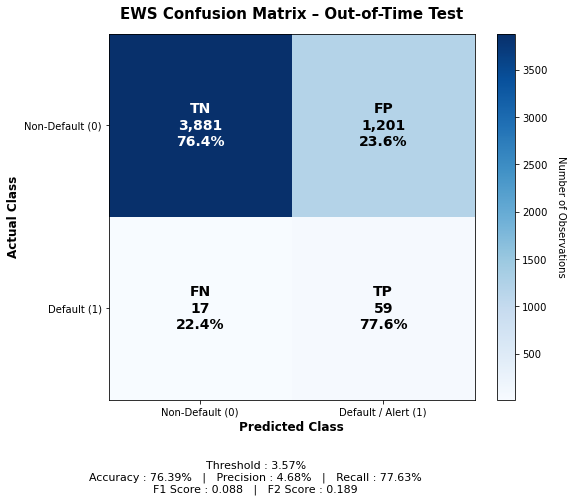

In [22]:
# ============================================================
# CONFUSION MATRIX + METRICS VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    accuracy_score
)

# ============================================================
# 1. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    oot["y"],
    pred_oot
)

tn, fp, fn, tp = cm.ravel()

# Persentase per actual class
cm_pct = (
    cm
    / cm.sum(axis=1, keepdims=True)
    * 100
)

# ============================================================
# 2. CALCULATE METRICS
# ============================================================

precision = precision_score(
    oot["y"],
    pred_oot
)

recall = recall_score(
    oot["y"],
    pred_oot
)

f1 = f1_score(
    oot["y"],
    pred_oot
)

# F2 lebih menekankan Recall
f2 = fbeta_score(
    oot["y"],
    pred_oot,
    beta=2
)

accuracy = accuracy_score(
    oot["y"],
    pred_oot
)

# ============================================================
# 3. LABEL CONFUSION MATRIX
# ============================================================

labels = np.array([
    [
        f"TN\n{tn:,}\n{cm_pct[0,0]:.1f}%",
        f"FP\n{fp:,}\n{cm_pct[0,1]:.1f}%"
    ],
    [
        f"FN\n{fn:,}\n{cm_pct[1,0]:.1f}%",
        f"TP\n{tp:,}\n{cm_pct[1,1]:.1f}%"
    ]
])

# ============================================================
# 4. PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 7)
)

im = ax.imshow(
    cm,
    cmap="Blues"
)

# Axis
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Non-Default (0)",
    "Default / Alert (1)"
])

ax.set_yticklabels([
    "Non-Default (0)",
    "Default (1)"
])

ax.set_xlabel(
    "Predicted Class",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Actual Class",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "EWS Confusion Matrix – Out-of-Time Test",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# ============================================================
# 5. ANNOTATION
# ============================================================

threshold_color = cm.max() / 2

for i in range(2):
    for j in range(2):

        text_color = (
            "white"
            if cm[i, j] > threshold_color
            else "black"
        )

        ax.text(
            j,
            i,
            labels[i, j],
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color=text_color
        )

# ============================================================
# 6. COLORBAR
# ============================================================

cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Number of Observations",
    rotation=270,
    labelpad=18
)

# ============================================================
# 7. METRIC SUMMARY
# ============================================================

metric_text = (
    f"Threshold : {threshold:.2%}\n"
    f"Accuracy : {accuracy:.2%}   |   "
    f"Precision : {precision:.2%}   |   "
    f"Recall : {recall:.2%}\n"
    f"F1 Score : {f1:.3f}   |   "
    f"F2 Score : {f2:.3f}"
)

fig.text(
    0.5,
    0.01,
    metric_text,
    ha="center",
    va="bottom",
    fontsize=11
)

plt.tight_layout(
    rect=[0, 0.11, 1, 1]
)

plt.show()

In [23]:
# ============================================================
# 14. RISK BANDS
# ============================================================

# Cutoff dibuat dari OOF train supaya tidak menggunakan OOT untuk
# menentukan batas risk band.

q80 = np.quantile(oof_p, 0.80)
q95 = np.quantile(oof_p, 0.95)

risk_band = pd.cut(
    p_oot,
    bins=[-np.inf, q80, q95, np.inf],
    labels=["LOW", "MEDIUM", "HIGH"],
    right=False
)

scored_oot = oot[
    [
        "facility_id",
        "cif_sk",
        "grup_id",
        "snapshot_date",
        "y"
    ]
].copy()

scored_oot["ews_score"] = p_oot
scored_oot["risk_band"] = risk_band

band_summary = (
    scored_oot
    .groupby("risk_band", observed=True)
    .agg(
        rows=("y", "size"),
        defaults=("y", "sum"),
        default_rate=("y", "mean"),
        min_score=("ews_score", "min"),
        max_score=("ews_score", "max")
    )
)

band_summary["share_portfolio"] = (
    band_summary["rows"] / len(scored_oot)
)

band_summary["capture_default"] = (
    band_summary["defaults"] / scored_oot["y"].sum()
)

display(band_summary)


,rows,defaults,default_rate,min_score,max_score,share_portfolio,capture_default
risk_band,,,,,,,
LOW,3313,14,0.004226,0.001866,0.016665,0.642303,0.184211
MEDIUM,1392,15,0.010776,0.016722,0.061442,0.269872,0.197368
HIGH,453,47,0.103753,0.061512,0.936667,0.087825,0.618421


In [24]:
# ============================================================
# 15. FEATURE DRIVER - SIMPLE BUSINESS CHECK
# ============================================================

# Tidak memakai coefficient sebagai satu-satunya interpretasi.
# Tampilkan observed default rate pada variabel utama.

tmp = train.copy()

tmp["credit_score_bucket"] = pd.qcut(
    tmp["app_skor_kredit"],
    q=5,
    duplicates="drop"
)

tmp["util_bucket"] = pd.qcut(
    tmp["perilaku_pemakaian_plafon"],
    q=5,
    duplicates="drop"
)

dpd_bins = [-1, 0, 29, 59, 89, 119, 179]
dpd_labels = ["0", "1-29", "30-59", "60-89", "90-119", "120-179"]

tmp["dpd_bucket"] = pd.cut(
    tmp["perilaku_dpd"],
    bins=dpd_bins,
    labels=dpd_labels
)

print("DEFAULT RATE BY CREDIT SCORE")
display(
    tmp.groupby("credit_score_bucket", observed=True)["y"]
       .agg(["count", "mean"])
)

print("DEFAULT RATE BY UTILIZATION")
display(
    tmp.groupby("util_bucket", observed=True)["y"]
       .agg(["count", "mean"])
)

print("DEFAULT RATE BY DPD")
display(
    tmp.groupby("dpd_bucket", observed=True)["y"]
       .agg(["count", "mean"])
)

print("DEFAULT RATE BY COVENANT VIOLATION")
display(
    tmp.groupby("perilaku_covenant_dilanggar")["y"]
       .agg(["count", "mean"])
)


DEFAULT RATE BY CREDIT SCORE


,count,mean
credit_score_bucket,,
"(0.019, 29.95]",19812,0.034726
"(29.95, 52.35]",19805,0.010906
"(52.35, 69.828]",19782,0.003286
"(69.828, 85.21]",19854,0.001511
"(85.21, 99.98]",19746,0.002076


DEFAULT RATE BY UTILIZATION


,count,mean
util_bucket,,
"(0.149, 0.572]",19838,0.006402
"(0.572, 0.688]",19773,0.006878
"(0.688, 0.78]",19807,0.008734
"(0.78, 0.874]",19795,0.012680
"(0.874, 1.0]",19786,0.017841


DEFAULT RATE BY DPD


,count,mean
dpd_bucket,,
0,92070,0.004801
1-29,2038,0.050049
30-59,2073,0.048722
60-89,2108,0.046964
90-119,595,0.304202
120-179,115,1.000000


DEFAULT RATE BY COVENANT VIOLATION


,count,mean
perilaku_covenant_dilanggar,,
0,26541,0.001959
1,34062,0.007662
2,31224,0.014156
3,7172,0.039738


# Sanity Check: apakah model benar-benar *early*?

Model EWS bisa terlihat bagus hanya karena mengenali obligor yang **sudah menunggak berat**.

Karena itu lakukan evaluasi kedua hanya pada snapshot dengan:
- `perilaku_dpd == 0`
- secara praktis masih performing / Kolektibilitas 1.

Jika PR-AUC turun drastis, berarti ABT saat ini lebih kuat untuk **imminent deterioration warning** daripada warning jauh sebelum delinquency.


In [25]:
# ============================================================
# 16. EARLY-STAGE SANITY CHECK: DPD = 0
# ============================================================

performing_oot = oot["perilaku_dpd"].eq(0)

y_perf = oot.loc[performing_oot, "y"]
p_perf = p_oot[performing_oot.values]

early_stage_metrics = ranking_metrics(
    y_perf,
    p_perf
)

print(
    "Performing OOT rows:",
    len(y_perf),
    "| defaults:",
    int(y_perf.sum()),
    "| prevalence:",
    y_perf.mean()
)

early_stage_metrics


Performing OOT rows: 4759 | defaults: 31 | prevalence: 0.006513973523849548


{'pr_auc': 0.10173309586884474,
 'roc_auc': 0.6927774138966213,
 'brier': 0.006655229310319263,
 'capture_top5': 0.25806451612903225,
 'precision_top5': 0.03361344537815126,
 'lift_top5': 5.160206017891027,
 'capture_top10': 0.5483870967741935,
 'precision_top10': 0.03571428571428571,
 'lift_top10': 5.482718894009216,
 'capture_top20': 0.5483870967741935,
 'precision_top20': 0.017857142857142856,
 'lift_top20': 2.741359447004608}

In [19]:
# ============================================================
# 17. SAVE CHAMPION + SCORED OOT
# ============================================================

joblib.dump(
    champion,
    "ews_logistic_champion.joblib"
)

scored_oot.to_csv(
    "ews_oot_scored.csv",
    index=False
)

print("Saved:")
print("- ews_logistic_champion.joblib")
print("- ews_oot_scored.csv")


Saved:
- ews_logistic_champion.joblib
- ews_oot_scored.csv


In [20]:
# ============================================================
# 18. SCORING FUNCTION FOR NEW SNAPSHOTS
# ============================================================

def score_ews(model, feature_df, features=FEATURES, q80_cut=None, q95_cut=None):

    result = feature_df.copy()

    score = model.predict_proba(
        result[features]
    )[:, 1]

    result["ews_score"] = score

    if (q80_cut is not None) and (q95_cut is not None):
        result["risk_band"] = pd.cut(
            result["ews_score"],
            bins=[-np.inf, q80_cut, q95_cut, np.inf],
            labels=["LOW", "MEDIUM", "HIGH"],
            right=False
        )

    return result


# Contoh:
# latest_scored = score_ews(
#     champion,
#     latest_snapshot_df,
#     q80_cut=q80,
#     q95_cut=q95
# )


# Save All File ke GitHub

In [26]:
# ============================================================
# EWS - ONE CELL PRODUCTION ARTIFACT EXPORT
# ============================================================
# JALANKAN SETELAH SELURUH MODELING EWS SELESAI
#
# Output:
#
# ml/artifacts/ews/
# ├── ews_xgboost_champion.joblib
# ├── ews_metadata.json
# ├── ews_feature_schema.json
# ├── ews_decision_policy.json
# ├── ews_metrics.json
# ├── ews_feature_importance.csv
# ├── ews_reference_stats.json
# ├── ews_risk_band_validation.csv
# ├── ews_requirements.txt
# └── ews_manifest.json
#
# ml/inference/
# ├── ews_feature_builder.py
# └── ews_predictor.py
# ============================================================


# ============================================================
# 0. IMPORT
# ============================================================

from pathlib import Path

import sys
import json
import hashlib
import joblib
import importlib
import importlib.metadata

import numpy as np
import pandas as pd

from sklearn.base import clone

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    accuracy_score,
    precision_recall_curve
)


print("=" * 80)
print("EWS PRODUCTION ARTIFACT EXPORT — XGBOOST")
print("=" * 80)


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "train",
    "oot",
    "FEATURES",
    "NUM_COLS",
    "CAT_COLS",
    "oof_p",
    "xgb_random_search"
]


missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]


if missing_variables:

    raise NameError(
        "Variable berikut belum tersedia.\n"
        "Jalankan seluruh proses modeling EWS terlebih dahulu:\n\n"
        + "\n".join(
            f"- {var}"
            for var in missing_variables
        )
    )


print("✅ Required modeling variables tersedia")


# ============================================================
# 2. GET CHAMPION — XGBOOST
# ============================================================

CHAMPION_NAME = "XGBoost"
MODEL_VERSION = "2.0.0"

# Best estimator hasil RandomizedSearchCV
best_xgb = (
    xgb_random_search
    .best_estimator_
)

# Development model hanya fit TRAIN untuk evaluasi OOT yang fair
development_model = clone(
    best_xgb
)

development_model.fit(
    train[FEATURES],
    train["y"]
)

print(
    "✅ Champion:",
    CHAMPION_NAME
)

print(
    "✅ Source  : xgb_random_search.best_estimator_"
)

# ============================================================
# 3. GET / RECALCULATE THRESHOLD
# ============================================================

TARGET_RECALL = 0.80


def threshold_for_min_recall_local(
    y_true,
    probability,
    min_recall=0.80
):

    precision, recall, thresholds = (
        precision_recall_curve(
            y_true,
            probability
        )
    )


    valid = np.where(
        recall[:-1]
        >= min_recall
    )[0]


    if len(valid) == 0:

        raise ValueError(
            "Tidak ada threshold yang memenuhi "
            f"recall >= {min_recall:.0%}"
        )


    idx = valid[
        np.argmax(
            precision[:-1][
                valid
            ]
        )
    ]


    return {

        "threshold":
            float(
                thresholds[idx]
            ),

        "precision":
            float(
                precision[idx]
            ),

        "recall":
            float(
                recall[idx]
            )
    }


# Selalu hitung ulang dari XGBoost OOF prediction.
# Jangan reuse threshold_info lama karena bisa berasal dari Logistic.
final_threshold_info = (
    threshold_for_min_recall_local(
        train["y"].values,
        oof_p,
        min_recall=
            TARGET_RECALL
    )
)


FINAL_THRESHOLD = float(
    final_threshold_info[
        "threshold"
    ]
)


print(
    "✅ Threshold:",
    FINAL_THRESHOLD
)


# ============================================================
# 4. RISK BAND CUT-OFF
# ============================================================

# Selalu dihitung dari TRAIN OOF,
# bukan dari OOT.

FINAL_Q80 = float(
    np.quantile(
        oof_p,
        0.80
    )
)


FINAL_Q95 = float(
    np.quantile(
        oof_p,
        0.95
    )
)


RISK_CUTOFFS = {

    "q80":
        FINAL_Q80,

    "q95":
        FINAL_Q95
}


print(
    "✅ Risk cutoffs:",
    RISK_CUTOFFS
)


# ============================================================
# 5. DIRECTORY
# ============================================================

# Notebook sekarang memakai:
# ../../data/gold
#
# Jadi kalau DATA_DIR tersedia,
# repo root diturunkan dari sana.

if "DATA_DIR" in globals():

    REPO_ROOT = (
        Path(
            DATA_DIR
        )
        .resolve()
        .parents[1]
    )

    ML_ROOT = (
        REPO_ROOT
        / "ml"
    )

else:

    # fallback jika notebook berada di ml/notebooks
    ML_ROOT = (
        Path("..")
        .resolve()
    )


ARTIFACT_DIR = (
    ML_ROOT
    / "artifacts"
    / "ews"
)


INFERENCE_DIR = (
    ML_ROOT
    / "inference"
)


ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


INFERENCE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "ML Root       :",
    ML_ROOT
)

print(
    "Artifact Dir  :",
    ARTIFACT_DIR
)

print(
    "Inference Dir :",
    INFERENCE_DIR
)


# ============================================================
# 6. HELPER FUNCTIONS
# ============================================================

def safe_float(value):

    if value is None:
        return None

    try:

        if pd.isna(value):
            return None

    except Exception:
        pass

    return float(value)


def json_safe(value):

    if isinstance(
        value,
        dict
    ):

        return {
            str(k):
                json_safe(v)

            for k, v
            in value.items()
        }


    if isinstance(
        value,
        (list, tuple)
    ):

        return [
            json_safe(v)
            for v in value
        ]


    if isinstance(
        value,
        (
            np.integer,
            np.int32,
            np.int64
        )
    ):

        return int(value)


    if isinstance(
        value,
        (
            np.floating,
            np.float32,
            np.float64
        )
    ):

        return float(value)


    if isinstance(
        value,
        np.bool_
    ):

        return bool(value)


    if isinstance(
        value,
        pd.Timestamp
    ):

        return str(value)


    return value


def ranking_metrics_local(
    y_true,
    probability
):

    y_true = np.asarray(
        y_true
    )

    probability = np.asarray(
        probability
    )


    result = {

        "pr_auc":
            float(
                average_precision_score(
                    y_true,
                    probability
                )
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    y_true,
                    probability
                )
            ),

        "brier":
            float(
                brier_score_loss(
                    y_true,
                    probability
                )
            )
    }


    order = np.argsort(
        -probability
    )


    prevalence = (
        y_true.mean()
    )


    total_positive = (
        y_true.sum()
    )


    for frac in [
        0.05,
        0.10,
        0.20
    ]:

        k = max(
            1,
            int(
                np.ceil(
                    len(y_true)
                    * frac
                )
            )
        )


        bucket_y = (
            y_true[
                order[:k]
            ]
        )


        capture = (
            bucket_y.sum()
            /
            total_positive
        )


        precision_top = (
            bucket_y.mean()
        )


        lift = (
            precision_top
            /
            prevalence
        )


        suffix = int(
            frac * 100
        )


        result[
            f"capture_top{suffix}"
        ] = float(capture)


        result[
            f"precision_top{suffix}"
        ] = float(
            precision_top
        )


        result[
            f"lift_top{suffix}"
        ] = float(lift)


    return result


def assign_risk_band_local(
    probability
):

    if probability < FINAL_Q80:

        return "LOW"

    elif probability < FINAL_Q95:

        return "MEDIUM"

    else:

        return "HIGH"


def sha256_file(path):

    sha256 = (
        hashlib.sha256()
    )


    with open(
        path,
        "rb"
    ) as f:

        for chunk in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b""
        ):

            sha256.update(
                chunk
            )


    return (
        sha256.hexdigest()
    )


# ============================================================
# 7. FINAL OOT PREDICTION — BEFORE FINAL REFIT
# ============================================================
# OOT HARUS dinilai sebelum OOT ikut difit ke final production model.

p_oot_export = (
    development_model
    .predict_proba(
        oot[FEATURES]
    )[:, 1]
)

pred_oot_export = (
    p_oot_export
    >= FINAL_THRESHOLD
).astype(int)

print(
    "✅ OOT prediction selesai (pre-final-refit)"
)

# ============================================================
# 8. OOT RANKING METRICS
# ============================================================

oot_ranking_metrics = (
    ranking_metrics_local(
        oot["y"].values,
        p_oot_export
    )
)


# ============================================================
# 9. THRESHOLD METRICS
# ============================================================

tn, fp, fn, tp = (
    confusion_matrix(
        oot["y"],
        pred_oot_export
    )
    .ravel()
)


threshold_metrics = {

    "threshold":
        float(
            FINAL_THRESHOLD
        ),

    "TP":
        int(tp),

    "FP":
        int(fp),

    "TN":
        int(tn),

    "FN":
        int(fn),

    "precision":
        float(
            precision_score(
                oot["y"],
                pred_oot_export,
                zero_division=0
            )
        ),

    "recall":
        float(
            recall_score(
                oot["y"],
                pred_oot_export,
                zero_division=0
            )
        ),

    "f1":
        float(
            f1_score(
                oot["y"],
                pred_oot_export,
                zero_division=0
            )
        ),

    "f2":
        float(
            fbeta_score(
                oot["y"],
                pred_oot_export,
                beta=2,
                zero_division=0
            )
        ),

    "accuracy":
        float(
            accuracy_score(
                oot["y"],
                pred_oot_export
            )
        ),

    "alert_rate":
        float(
            pred_oot_export.mean()
        )
}


print(
    "\nOOT RANKING METRICS"
)

display(
    pd.DataFrame(
        [
            oot_ranking_metrics
        ]
    )
)


print(
    "\nOOT THRESHOLD METRICS"
)

display(
    pd.DataFrame(
        [
            threshold_metrics
        ]
    )
)


# ============================================================
# 10. RISK BAND VALIDATION
# ============================================================

risk_band_export = [

    assign_risk_band_local(p)

    for p
    in p_oot_export
]


risk_validation_df = (
    pd.DataFrame({

        "y":
            oot["y"]
            .to_numpy(),

        "ews_score":
            p_oot_export,

        "risk_band":
            risk_band_export
    })
)


risk_band_validation = (
    risk_validation_df
    .groupby(
        "risk_band",
        observed=True
    )
    .agg(

        rows=(
            "y",
            "size"
        ),

        defaults=(
            "y",
            "sum"
        ),

        default_rate=(
            "y",
            "mean"
        ),

        min_score=(
            "ews_score",
            "min"
        ),

        max_score=(
            "ews_score",
            "max"
        )
    )
    .reindex(
        [
            "LOW",
            "MEDIUM",
            "HIGH"
        ]
    )
)


risk_band_validation[
    "share_portfolio"
] = (
    risk_band_validation[
        "rows"
    ]
    /
    len(
        risk_validation_df
    )
)


risk_band_validation[
    "capture_default"
] = (
    risk_band_validation[
        "defaults"
    ]
    /
    risk_validation_df[
        "y"
    ].sum()
)


risk_band_validation = (
    risk_band_validation
    .reset_index()
)


RISK_BAND_PATH = (
    ARTIFACT_DIR
    / "ews_risk_band_validation.csv"
)


risk_band_validation.to_csv(
    RISK_BAND_PATH,
    index=False
)


print(
    "✅ Saved:",
    RISK_BAND_PATH
)


display(
    risk_band_validation
)


# ============================================================
# 11. EARLY-STAGE SANITY CHECK
# ============================================================

early_stage_metrics_export = None


if (
    "perilaku_dpd"
    in oot.columns
):

    performing_mask = (
        oot[
            "perilaku_dpd"
        ].eq(0)
    )


    y_early = (
        oot.loc[
            performing_mask,
            "y"
        ]
    )


    p_early = (
        p_oot_export[
            performing_mask.values
        ]
    )


    if (
        len(y_early) > 0
        and
        y_early.nunique() > 1
    ):

        early_stage_metrics_export = (
            ranking_metrics_local(
                y_early.values,
                p_early
            )
        )


        early_stage_metrics_export[
            "rows"
        ] = int(
            len(y_early)
        )


        early_stage_metrics_export[
            "defaults"
        ] = int(
            y_early.sum()
        )


        early_stage_metrics_export[
            "prevalence"
        ] = float(
            y_early.mean()
        )


print(
    "✅ Early-stage sanity check selesai"
)


# ============================================================
# 12. FINAL REFIT ON ALL LABELED DATA — TRAIN + OOT
# ============================================================
# Semua evaluasi OOT sudah selesai di atas.
# Sekarang model di-fit ulang dari nol pada seluruh data berlabel,
# BARU setelah itu model production disimpan.

all_labeled_data = pd.concat(
    [
        train,
        oot
    ],
    axis=0,
    ignore_index=True
)

final_model = clone(
    best_xgb
)

final_model.fit(
    all_labeled_data[FEATURES],
    all_labeled_data["y"]
)

print("\n" + "=" * 80)
print("FINAL PRODUCTION REFIT")
print("=" * 80)
print("Train rows       :", len(train))
print("OOT rows         :", len(oot))
print("Final train rows :", len(all_labeled_data))
print("Final defaults   :", int(all_labeled_data["y"].sum()))
print("✅ final_model fit pada TRAIN + OOT")


# ============================================================
# 13. SAVE MAIN EWS ARTIFACT
# ============================================================

ews_artifact = {

    "model":
        final_model,

    "champion_name":
        CHAMPION_NAME,

    "model_version":
        MODEL_VERSION,

    "target":
        "y_default_6bln",

    "target_definition":
        (
            "Default within 6 months "
            "after snapshot"
        ),

    "features":
        list(
            FEATURES
        ),

    "numeric_features":
        list(
            NUM_COLS
        ),

    "categorical_features":
        list(
            CAT_COLS
        ),

    "threshold":
        float(
            FINAL_THRESHOLD
        ),

    "target_recall":
        TARGET_RECALL,

    "risk_cutoffs":
        RISK_CUTOFFS,

    "risk_labels":
        [
            "LOW",
            "MEDIUM",
            "HIGH"
        ],

    "engineered_features_required":
        True,

    "feature_builder_required_for_raw_history":
        True,

    "final_refit_includes_oot":
        True,

    "final_refit_rows":
        int(len(all_labeled_data)),

    "oot_metrics_are_pre_final_refit":
        True,

    "calibrated":
        False
}


EWS_MODEL_PATH = (
    ARTIFACT_DIR
    / "ews_xgboost_champion.joblib"
)


joblib.dump(
    ews_artifact,
    EWS_MODEL_PATH
)


print(
    "✅ Saved:",
    EWS_MODEL_PATH
)


# ============================================================
# 13. FEATURE SCHEMA
# ============================================================

feature_schema = {

    "model":
        CHAMPION_NAME,

    "model_version":
        MODEL_VERSION,

    "target":
        "y_default_6bln",

    "number_of_features":
        int(
            len(FEATURES)
        ),

    "number_of_raw_features":
        int(
            len(
                globals().get(
                    "RAW_FEATURES",
                    []
                )
            )
        ),

    "number_of_engineered_features":
        int(
            len(
                globals().get(
                    "ENGINEERED_FEATURES",
                    []
                )
            )
        ),

    "features": {}
}


engineered_feature_list = list(
    globals().get(
        "ENGINEERED_FEATURES",
        []
    )
)


for col in FEATURES:

    series = (
        all_labeled_data[col]
    )


    if col in CAT_COLS:

        categories = (
            series
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )


        feature_schema[
            "features"
        ][col] = {

            "type":
                "categorical",

            "dtype":
                str(
                    series.dtype
                ),

            "nullable":
                bool(
                    series.isna().any()
                ),

            "engineered":
                bool(
                    col
                    in engineered_feature_list
                ),

            "known_categories":
                sorted(
                    categories
                )
        }


    else:

        clean = (
            pd.to_numeric(
                series,
                errors="coerce"
            )
            .dropna()
            .astype(float)
        )


        feature_schema[
            "features"
        ][col] = {

            "type":
                "numeric",

            "dtype":
                str(
                    series.dtype
                ),

            "nullable":
                bool(
                    series.isna().any()
                ),

            "engineered":
                bool(
                    col
                    in engineered_feature_list
                ),

            "min":
                float(
                    clean.min()
                )
                if len(clean)
                else None,

            "max":
                float(
                    clean.max()
                )
                if len(clean)
                else None
        }


FEATURE_SCHEMA_PATH = (
    ARTIFACT_DIR
    / "ews_feature_schema.json"
)


with open(
    FEATURE_SCHEMA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(
            feature_schema
        ),
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    FEATURE_SCHEMA_PATH
)


# ============================================================
# 14. DECISION POLICY
# ============================================================

decision_policy = {

    "model":
        CHAMPION_NAME,

    "model_version":
        MODEL_VERSION,

    "output":
        "6-month EWS default risk score",

    "target":
        "y_default_6bln",

    "alert_policy": {

        "threshold":
            float(
                FINAL_THRESHOLD
            ),

        "selection_population":
            (
                "Training out-of-fold "
                "predictions"
            ),

        "minimum_recall":
            float(
                TARGET_RECALL
            ),

        "selection_rule":
            (
                "Among thresholds satisfying "
                "minimum recall, choose the "
                "threshold with highest precision."
            )
    },

    "risk_band": {

        "method":
            (
                "Quantiles of training "
                "out-of-fold probability"
            ),

        "LOW":
            (
                f"score < {FINAL_Q80:.8f}"
            ),

        "MEDIUM":
            (
                f"{FINAL_Q80:.8f} <= score "
                f"< {FINAL_Q95:.8f}"
            ),

        "HIGH":
            (
                f"score >= {FINAL_Q95:.8f}"
            )
    },

    "risk_band_note":
        (
            "Risk band is an operational / "
            "interpretive ranking rule from "
            "training OOF scores, not an "
            "official bank policy threshold."
        ),

    "probability_note":
        (
            "EWS score is used primarily as "
            "a ranking/alert score. It should "
            "not automatically be interpreted "
            "as a regulatory calibrated PD."
        )
}


DECISION_POLICY_PATH = (
    ARTIFACT_DIR
    / "ews_decision_policy.json"
)


with open(
    DECISION_POLICY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        decision_policy,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    DECISION_POLICY_PATH
)


# ============================================================
# 15. METADATA
# ============================================================

# Ambil parameter XGBoost dari final production model
if (
    hasattr(final_model, "named_steps")
    and
    "model" in final_model.named_steps
):

    xgb_estimator = (
        final_model
        .named_steps["model"]
    )

else:

    xgb_estimator = final_model


xgb_params = (
    xgb_estimator
    .get_params()
)


metadata = {

    "model_name":
        "Early Warning System",

    "champion_name":
        CHAMPION_NAME,

    "model_family":
        "XGBoost Classifier",

    "model_version":
        MODEL_VERSION,

    "problem_type":
        "binary classification",

    "target":
        "y_default_6bln",

    "target_definition":
        "Whether facility defaults within 6 months after snapshot",

    "development_training": {
        "rows": int(len(train)),
        "defaults": int(train["y"].sum()),
        "default_rate": float(train["y"].mean()),
        "groups": (
            int(train["grup_id"].nunique())
            if "grup_id" in train.columns
            else None
        )
    },

    "oot_evaluation_pre_final_refit": {
        "rows": int(len(oot)),
        "defaults": int(oot["y"].sum()),
        "default_rate": float(oot["y"].mean())
    },

    "final_production_refit": {
        "includes_train": True,
        "includes_oot": True,
        "rows": int(len(all_labeled_data)),
        "defaults": int(all_labeled_data["y"].sum()),
        "default_rate": float(all_labeled_data["y"].mean())
    },

    "number_of_features":
        int(len(FEATURES)),

    "features":
        list(FEATURES),

    "numeric_features":
        list(NUM_COLS),

    "categorical_features":
        list(CAT_COLS),

    "threshold":
        float(FINAL_THRESHOLD),

    "risk_cutoffs":
        RISK_CUTOFFS,

    "hyperparameters":
        json_safe(xgb_params),

    "feature_engineering":
        "Current + past-only lag/delta/rolling features",

    "calibrated":
        False
}


METADATA_PATH = (
    ARTIFACT_DIR
    / "ews_metadata.json"
)


with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(metadata),
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    METADATA_PATH
)

# ============================================================
# 16. METRICS
# ============================================================

cv_metrics_export = None


if "cv_summary" in globals():

    cv_metrics_export = (
        cv_summary
        .reset_index()
        .to_dict(
            orient="records"
        )
    )


xgb_tuning_export = None


if "xgb_random_search" in globals():

    xgb_tuning_export = {

        "best_cv_pr_auc":
            float(
                xgb_random_search
                .best_score_
            ),

        "best_params":
            json_safe(
                xgb_random_search
                .best_params_
            )
    }


metrics_export = {

    "model":
        CHAMPION_NAME,

    "model_version":
        MODEL_VERSION,

    "cross_validation":
        cv_metrics_export,

    "xgboost_champion_tuning":
        xgb_tuning_export,

    "oot_ranking":
        oot_ranking_metrics,

    "operational_threshold":
        threshold_metrics,

    "oof_threshold_selection":
        final_threshold_info,

    "risk_cutoffs":
        RISK_CUTOFFS,

    "early_stage_dpd_zero":
        early_stage_metrics_export
}


METRICS_PATH = (
    ARTIFACT_DIR
    / "ews_metrics.json"
)


with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(
            metrics_export
        ),
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    METRICS_PATH
)


# ============================================================
# 17. FEATURE IMPORTANCE — XGBOOST
# ============================================================

if (
    hasattr(final_model, "named_steps")
    and
    "pre" in final_model.named_steps
):

    preprocessor = (
        final_model
        .named_steps["pre"]
    )

    xgb_model = (
        final_model
        .named_steps["model"]
    )

    try:
        transformed_feature_names = (
            preprocessor
            .get_feature_names_out()
        )
    except Exception:
        transformed_feature_names = [
            f"transformed_feature_{i}"
            for i in range(
                len(xgb_model.feature_importances_)
            )
        ]

else:

    xgb_model = final_model
    transformed_feature_names = list(FEATURES)


feature_importances = (
    xgb_model
    .feature_importances_
)


if (
    len(transformed_feature_names)
    !=
    len(feature_importances)
):

    transformed_feature_names = [
        f"transformed_feature_{i}"
        for i in range(
            len(feature_importances)
        )
    ]


ews_feature_importance = (
    pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": feature_importances
    })
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


FEATURE_IMPORTANCE_PATH = (
    ARTIFACT_DIR
    / "ews_feature_importance.csv"
)


ews_feature_importance.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False
)


print(
    "✅ Saved:",
    FEATURE_IMPORTANCE_PATH
)


display(
    ews_feature_importance.head(25)
)

# ============================================================
# 18. FEATURE REFERENCE STATISTICS
# ============================================================

reference_stats = {}


for col in FEATURES:

    series = (
        all_labeled_data[col]
    )


    # --------------------------------------------------------
    # BOOLEAN
    # --------------------------------------------------------

    if pd.api.types.is_bool_dtype(
        series
    ):

        clean = (
            series
            .dropna()
            .astype(int)
        )


        reference_stats[col] = {

            "type":
                "boolean",

            "count":
                int(
                    len(clean)
                ),

            "missing_count":
                int(
                    series
                    .isna()
                    .sum()
                ),

            "true_count":
                int(
                    clean.sum()
                )
                if len(clean)
                else 0,

            "false_count":
                int(
                    (clean == 0)
                    .sum()
                )
                if len(clean)
                else 0,

            "true_rate":
                float(
                    clean.mean()
                )
                if len(clean)
                else None
        }


    # --------------------------------------------------------
    # CATEGORICAL
    # --------------------------------------------------------

    elif col in CAT_COLS:

        counts = (
            series
            .astype("string")
            .value_counts(
                dropna=False
            )
            .head(50)
        )


        reference_stats[col] = {

            "type":
                "categorical",

            "count":
                int(
                    series
                    .notna()
                    .sum()
                ),

            "missing_count":
                int(
                    series
                    .isna()
                    .sum()
                ),

            "n_unique":
                int(
                    series
                    .nunique(
                        dropna=True
                    )
                ),

            "top_categories": {

                str(k):
                    int(v)

                for k, v
                in counts.items()
            }
        }


    # --------------------------------------------------------
    # NUMERIC
    # --------------------------------------------------------

    else:

        clean = (
            pd.to_numeric(
                series,
                errors="coerce"
            )
            .dropna()
            .astype(float)
        )


        reference_stats[col] = {

            "type":
                "numeric",

            "count":
                int(
                    len(clean)
                ),

            "missing_count":
                int(
                    series
                    .isna()
                    .sum()
                ),

            "mean":
                float(
                    clean.mean()
                )
                if len(clean)
                else None,

            "median":
                float(
                    clean.median()
                )
                if len(clean)
                else None,

            "p25":
                float(
                    clean.quantile(
                        0.25
                    )
                )
                if len(clean)
                else None,

            "p75":
                float(
                    clean.quantile(
                        0.75
                    )
                )
                if len(clean)
                else None,

            "p95":
                float(
                    clean.quantile(
                        0.95
                    )
                )
                if len(clean)
                else None,

            "min":
                float(
                    clean.min()
                )
                if len(clean)
                else None,

            "max":
                float(
                    clean.max()
                )
                if len(clean)
                else None
        }


REFERENCE_PATH = (
    ARTIFACT_DIR
    / "ews_reference_stats.json"
)


with open(
    REFERENCE_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(
            reference_stats
        ),
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    REFERENCE_PATH
)


# ============================================================
# 19. REQUIREMENTS
# ============================================================

packages = [
    "numpy",
    "pandas",
    "scikit-learn",
    "xgboost",
    "joblib"
]


requirements = []


for package in packages:

    try:

        version = (
            importlib.metadata
            .version(
                package
            )
        )


        requirements.append(
            f"{package}=={version}"
        )

    except Exception:

        pass


REQUIREMENTS_PATH = (
    ARTIFACT_DIR
    / "ews_requirements.txt"
)


REQUIREMENTS_PATH.write_text(
    "\n".join(
        requirements
    ),
    encoding="utf-8"
)


print(
    "✅ Saved:",
    REQUIREMENTS_PATH
)


# ============================================================
# 20. CREATE EWS FEATURE BUILDER
# ============================================================
# PENTING:
#
# Engineered features EWS membutuhkan
# history beberapa snapshot facility.
#
# Jangan hitung dpd_delta_3m dll.
# dari satu snapshot saja.
# ============================================================

ews_feature_builder_code = r'''
import pandas as pd


def build_ews_features(raw_df):

    """
    Build EWS current/past-only features.

    Input harus mempunyai history snapshot per facility
    agar lag/delta features bermakna.
    """

    required_columns = [
        "facility_id",
        "snapshot_date",
        "app_rating_internal",
        "perilaku_dpd",
        "perilaku_dpd_maks_3bln",
        "perilaku_kol_maks_3bln",
        "perilaku_kolektibilitas",
        "perilaku_pemakaian_plafon",
        "perilaku_covenant_dilanggar"
    ]


    missing = [
        col
        for col in required_columns
        if col not in raw_df.columns
    ]


    if missing:

        raise ValueError(
            "Missing columns untuk EWS feature builder: "
            + ", ".join(missing)
        )


    x = (
        raw_df
        .copy()
    )


    x["snapshot_date"] = (
        pd.to_datetime(
            x["snapshot_date"]
        )
    )


    x = (
        x
        .sort_values(
            [
                "facility_id",
                "snapshot_date"
            ]
        )
        .copy()
    )


    rating_order = {
        "AAA": 1,
        "AA": 2,
        "A": 3,
        "BBB": 4,
        "BB": 5,
        "B": 6,
        "CCC": 7,
        "CC": 8,
        "C": 9,
        "D": 10
    }


    x[
        "app_rating_ord"
    ] = (
        x[
            "app_rating_internal"
        ]
        .map(
            rating_order
        )
        .astype(float)
    )


    x[
        "dpd_gap_vs_max3m"
    ] = (
        x[
            "perilaku_dpd_maks_3bln"
        ]
        -
        x[
            "perilaku_dpd"
        ]
    )


    x[
        "kol_gap_vs_max3m"
    ] = (
        x[
            "perilaku_kol_maks_3bln"
        ]
        -
        x[
            "perilaku_kolektibilitas"
        ]
    )


    lag_map = {

        "perilaku_dpd":
            "dpd",

        "perilaku_pemakaian_plafon":
            "util",

        "perilaku_covenant_dilanggar":
            "covenant",

        "perilaku_kolektibilitas":
            "kol"
    }


    for (
        source_col,
        short_name
    ) in lag_map.items():

        g = (
            x
            .groupby(
                "facility_id"
            )[
                source_col
            ]
        )


        x[
            f"{short_name}_delta_1m"
        ] = (
            x[
                source_col
            ]
            -
            g.shift(1)
        )


        x[
            f"{short_name}_delta_3m"
        ] = (
            x[
                source_col
            ]
            -
            g.shift(3)
        )


    x[
        "util_avg_3m"
    ] = (
        x
        .groupby(
            "facility_id"
        )[
            "perilaku_pemakaian_plafon"
        ]
        .transform(

            lambda s:
                s.rolling(
                    3,
                    min_periods=1
                )
                .mean()

        )
    )


    x[
        "util_vs_avg3m"
    ] = (
        x[
            "perilaku_pemakaian_plafon"
        ]
        -
        x[
            "util_avg_3m"
        ]
    )


    return x
'''


EWS_FEATURE_BUILDER_PATH = (
    INFERENCE_DIR
    / "ews_feature_builder.py"
)


EWS_FEATURE_BUILDER_PATH.write_text(
    ews_feature_builder_code,
    encoding="utf-8"
)


print(
    "✅ Created:",
    EWS_FEATURE_BUILDER_PATH
)


# ============================================================
# 21. CREATE EWS PREDICTOR
# ============================================================

ews_predictor_code = r'''
from pathlib import Path

import joblib
import numpy as np
import pandas as pd


try:

    from .ews_feature_builder import (
        build_ews_features
    )

except ImportError:

    from ews_feature_builder import (
        build_ews_features
    )


# ============================================================
# ARTIFACT PATH
# ============================================================

ML_ROOT = (
    Path(__file__)
    .resolve()
    .parents[1]
)


ARTIFACT_PATH = (
    ML_ROOT
    / "artifacts"
    / "ews"
    / "ews_xgboost_champion.joblib"
)


_ARTIFACT = joblib.load(
    ARTIFACT_PATH
)


# ============================================================
# RISK BAND
# ============================================================

def _risk_band(
    probability
):

    q80 = (
        _ARTIFACT[
            "risk_cutoffs"
        ][
            "q80"
        ]
    )


    q95 = (
        _ARTIFACT[
            "risk_cutoffs"
        ][
            "q95"
        ]
    )


    if probability < q80:

        return "LOW"

    elif probability < q95:

        return "MEDIUM"

    else:

        return "HIGH"


# ============================================================
# SCORE PRE-BUILT FEATURES
# ============================================================

def predict_ews(
    input_data,
    strict=False
):

    """
    Score EWS using pre-built model features.

    input_data:
        dict atau pandas.DataFrame

    strict=False:
        Missing columns dibuat NaN sehingga
        pipeline imputer dapat menangani.

        Output tetap menampilkan feature
        completeness dan missing features.

    strict=True:
        Error jika ada model feature yang
        tidak tersedia.
    """


    # --------------------------------------------------------
    # Input conversion
    # --------------------------------------------------------

    if isinstance(
        input_data,
        dict
    ):

        df = pd.DataFrame(
            [input_data]
        )

    elif isinstance(
        input_data,
        pd.DataFrame
    ):

        df = (
            input_data
            .copy()
        )

    else:

        raise TypeError(
            "input_data harus berupa "
            "dict atau pandas.DataFrame"
        )


    model = (
        _ARTIFACT[
            "model"
        ]
    )


    features = (
        _ARTIFACT[
            "features"
        ]
    )


    threshold = float(
        _ARTIFACT[
            "threshold"
        ]
    )


    # --------------------------------------------------------
    # Missing columns
    # --------------------------------------------------------

    missing_features = [

        col
        for col in features

        if col not in df.columns
    ]


    if (
        strict
        and
        missing_features
    ):

        raise ValueError(
            "Missing EWS features: "
            + ", ".join(
                missing_features
            )
        )


    # Pipeline mempunyai imputer.
    # Buat schema lengkap agar
    # ColumnTransformer tidak gagal.

    x = (
        df.copy()
    )


    for col in missing_features:

        x[col] = np.nan


    x = (
        x[
            features
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Data completeness
    # --------------------------------------------------------

    available_count = (
        x.notna()
        .sum(
            axis=1
        )
    )


    completeness = (
        available_count
        /
        len(
            features
        )
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    score = (
        model
        .predict_proba(
            x
        )[:, 1]
    )


    alert = (
        score
        >= threshold
    ).astype(int)


    # --------------------------------------------------------
    # Result
    # --------------------------------------------------------

    result = (
        df.copy()
    )


    result[
        "ews_score"
    ] = score


    result[
        "ews_score_pct"
    ] = (
        score
        * 100
    )


    result[
        "ews_alert"
    ] = alert


    result[
        "ews_alert_label"
    ] = np.where(
        alert == 1,
        "ALERT",
        "NO ALERT"
    )


    result[
        "risk_band"
    ] = [

        _risk_band(p)

        for p
        in score
    ]


    result[
        "decision_threshold"
    ] = threshold


    result[
        "feature_completeness"
    ] = completeness.values


    result[
        "missing_feature_count"
    ] = (
        len(
            features
        )
        -
        available_count.values
    )


    result[
        "model_name"
    ] = (
        _ARTIFACT[
            "champion_name"
        ]
    )


    return result


# ============================================================
# SCORE FROM RAW HISTORY
# ============================================================

def predict_ews_from_history(
    raw_history_df,
    latest_only=True,
    strict=True
):

    """
    Build lag/delta/rolling features from historical
    facility snapshots, then score EWS.

    latest_only=True:
        Hanya score snapshot terbaru tiap facility.
    """


    feature_df = (
        build_ews_features(
            raw_history_df
        )
    )


    if latest_only:

        feature_df = (
            feature_df
            .sort_values(
                [
                    "facility_id",
                    "snapshot_date"
                ]
            )
            .groupby(
                "facility_id",
                as_index=False
            )
            .tail(1)
            .copy()
        )


    return predict_ews(
        feature_df,
        strict=strict
    )


# ============================================================
# QWEN / AGENT TOOL
# ============================================================

def predict_ews_tool(
    customer_data
):

    result = (
        predict_ews(
            customer_data,
            strict=False
        )
        .iloc[0]
    )


    input_columns = (
        set(
            customer_data.keys()
        )
        if isinstance(
            customer_data,
            dict
        )
        else set()
    )


    features = (
        _ARTIFACT[
            "features"
        ]
    )


    missing_features = [

        feature
        for feature in features

        if feature not in input_columns
    ]


    return {

        "model":
            str(
                result[
                    "model_name"
                ]
            ),

        "prediction_horizon":
            "6 months",

        "ews_score":
            round(
                float(
                    result[
                        "ews_score"
                    ]
                ),
                6
            ),

        "ews_score_pct":
            round(
                float(
                    result[
                        "ews_score_pct"
                    ]
                ),
                2
            ),

        "risk_band":
            str(
                result[
                    "risk_band"
                ]
            ),

        "alert_flag":
            int(
                result[
                    "ews_alert"
                ]
            ),

        "alert_label":
            str(
                result[
                    "ews_alert_label"
                ]
            ),

        "decision_threshold":
            round(
                float(
                    result[
                        "decision_threshold"
                    ]
                ),
                6
            ),

        "feature_completeness":
            round(
                float(
                    result[
                        "feature_completeness"
                    ]
                ),
                4
            ),

        "missing_features":
            missing_features,

        "warning":
            (
                None
                if len(
                    missing_features
                ) == 0
                else
                "Some EWS features are missing and "
                "were imputed by the model pipeline. "
                "Historical features should preferably "
                "be generated from facility history."
            )
    }
'''


EWS_PREDICTOR_PATH = (
    INFERENCE_DIR
    / "ews_predictor.py"
)


EWS_PREDICTOR_PATH.write_text(
    ews_predictor_code,
    encoding="utf-8"
)


print(
    "✅ Created:",
    EWS_PREDICTOR_PATH
)


# ============================================================
# 22. MANIFEST
# ============================================================

artifact_files = [

    EWS_MODEL_PATH,
    METADATA_PATH,
    FEATURE_SCHEMA_PATH,
    DECISION_POLICY_PATH,
    METRICS_PATH,
    FEATURE_IMPORTANCE_PATH,
    REFERENCE_PATH,
    RISK_BAND_PATH,
    REQUIREMENTS_PATH,
    EWS_FEATURE_BUILDER_PATH,
    EWS_PREDICTOR_PATH
]


manifest = {

    "model":
        CHAMPION_NAME,

    "version":
        MODEL_VERSION,

    "files": {}
}


for file_path in artifact_files:

    if not file_path.exists():

        raise FileNotFoundError(
            "Artifact belum terbentuk: "
            + str(
                file_path
            )
        )


    manifest[
        "files"
    ][
        file_path.name
    ] = {

        "sha256":
            sha256_file(
                file_path
            ),

        "size_bytes":
            int(
                file_path
                .stat()
                .st_size
            )
    }


MANIFEST_PATH = (
    ARTIFACT_DIR
    / "ews_manifest.json"
)


with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "✅ Saved:",
    MANIFEST_PATH
)


# ============================================================
# 23. TEST ARTIFACT RELOAD
# ============================================================

loaded_ews_artifact = (
    joblib.load(
        EWS_MODEL_PATH
    )
)


assert (
    loaded_ews_artifact[
        "champion_name"
    ]
    ==
    CHAMPION_NAME
)


assert (
    loaded_ews_artifact[
        "features"
    ]
    ==
    list(
        FEATURES
    )
)


assert np.isclose(
    loaded_ews_artifact[
        "threshold"
    ],
    FINAL_THRESHOLD
)


print(
    "✅ EWS artifact berhasil di-load ulang"
)


# ============================================================
# 24. IMPORT PRODUCTION PREDICTOR
# ============================================================

if str(
    INFERENCE_DIR
) not in sys.path:

    sys.path.insert(
        0,
        str(
            INFERENCE_DIR
        )
    )


# Hapus module cache jika sebelumnya pernah import
for module_name in [
    "ews_predictor",
    "ews_feature_builder"
]:

    if module_name in sys.modules:

        del sys.modules[
            module_name
        ]


import ews_feature_builder
import ews_predictor


ews_feature_builder = (
    importlib.reload(
        ews_feature_builder
    )
)


ews_predictor = (
    importlib.reload(
        ews_predictor
    )
)


print(
    "✅ ews_predictor berhasil di-load"
)


# ============================================================
# 25. VERIFY SAVED PRODUCTION MODEL == FINAL MODEL
# ============================================================
# Karena final model sudah melihat OOT, JANGAN bandingkan lagi
# production score dengan p_oot_export. p_oot_export adalah score
# development model sebelum final refit.

verification_sample = (
    all_labeled_data[FEATURES]
    .head(
        min(100, len(all_labeled_data))
    )
    .copy()
)

expected_final_score = (
    final_model
    .predict_proba(
        verification_sample
    )[:, 1]
)

loaded_final_score = (
    loaded_ews_artifact["model"]
    .predict_proba(
        verification_sample
    )[:, 1]
)

max_difference = (
    np.max(
        np.abs(
            expected_final_score
            - loaded_final_score
        )
    )
)

print(
    "Maximum saved-model difference:",
    max_difference
)

assert np.allclose(
    expected_final_score,
    loaded_final_score,
    atol=1e-12,
    rtol=0
), (
    "ERROR: saved production model berbeda "
    "dengan final_model."
)

print(
    "✅ Saved production model identik dengan final_model"
)

# ============================================================
# 26. VERIFY PRODUCTION PREDICTOR == SAVED FINAL MODEL
# ============================================================

production_result = (
    ews_predictor
    .predict_ews(
        verification_sample,
        strict=True
    )
)

production_score = (
    production_result["ews_score"]
    .to_numpy()
)

assert np.allclose(
    production_score,
    loaded_final_score,
    atol=1e-12,
    rtol=0
)

print(
    "✅ Production predictor identik dengan saved final model"
)

# ============================================================
# 27. TEST AGENT TOOL OUTPUT
# ============================================================

sample_customer = (
    verification_sample
    .iloc[0]
    .to_dict()
)


tool_output = (
    ews_predictor
    .predict_ews_tool(
        sample_customer
    )
)


print(
    "\n"
    + "=" * 80
)

print(
    "QWEN / AGENT TOOL OUTPUT"
)

print(
    "=" * 80
)


print(
    json.dumps(
        tool_output,
        indent=2,
        ensure_ascii=False
    )
)


# ============================================================
# 28. ARTIFACT AUDIT
# ============================================================

print(
    "\n"
    + "=" * 80
)

print(
    "EWS ARTIFACT FILES"
)

print(
    "=" * 80
)


for file_path in sorted(
    ARTIFACT_DIR.iterdir()
):

    print(
        f"{file_path.name:<40}"
        f"{file_path.stat().st_size / 1024:>12.2f} KB"
    )


print(
    "\n"
    + "=" * 80
)

print(
    "EWS INFERENCE FILES"
)

print(
    "=" * 80
)


print(
    EWS_FEATURE_BUILDER_PATH
)

print(
    EWS_PREDICTOR_PATH
)


# ============================================================
# 29. FINAL SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 80
)

print(
    "EWS EXPORT COMPLETE"
)

print(
    "=" * 80
)


print(
    "✅ Champion       :",
    CHAMPION_NAME
)

print(
    "✅ Threshold      :",
    round(
        FINAL_THRESHOLD,
        6
    )
)

print(
    "✅ Q80            :",
    round(
        FINAL_Q80,
        6
    )
)

print(
    "✅ Q95            :",
    round(
        FINAL_Q95,
        6
    )
)

print(
    "✅ PR-AUC OOT     :",
    round(
        oot_ranking_metrics[
            "pr_auc"
        ],
        4
    )
)

print(
    "✅ ROC-AUC OOT    :",
    round(
        oot_ranking_metrics[
            "roc_auc"
        ],
        4
    )
)

print(
    "✅ Recall OOT     :",
    round(
        threshold_metrics[
            "recall"
        ],
        4
    )
)

print(
    "✅ Precision OOT  :",
    round(
        threshold_metrics[
            "precision"
        ],
        4
    )
)

print(
    "✅ F1 OOT         :",
    round(
        threshold_metrics[
            "f1"
        ],
        4
    )
)

print(
    "✅ F2 OOT         :",
    round(
        threshold_metrics[
            "f2"
        ],
        4
    )
)

print(
    "✅ Accuracy OOT   :",
    round(
        threshold_metrics[
            "accuracy"
        ],
        4
    )
)

print(
    "✅ Alert Rate     :",
    round(
        threshold_metrics[
            "alert_rate"
        ],
        4
    )
)

print(
    "✅ Final Fit Rows :",
    len(all_labeled_data)
)

print(
    "✅ Includes OOT   :",
    True
)

print(
    "✅ Model          :",
    EWS_MODEL_PATH
)

print(
    "✅ Predictor      :",
    EWS_PREDICTOR_PATH
)

print(
    "✅ Feature Builder:",
    EWS_FEATURE_BUILDER_PATH
)

print(
    "✅ Manifest       :",
    MANIFEST_PATH
)

print(
    "\n✅ EWS SIAP DIGUNAKAN "
    "UNTUK STREAMLIT / QWEN TOOL CALLING"
)

EWS PRODUCTION ARTIFACT EXPORT — XGBOOST
✅ Required modeling variables tersedia
✅ Champion: XGBoost
✅ Source  : xgb_random_search.best_estimator_
✅ Threshold: 0.03570814058184624
✅ Risk cutoffs: {'q80': 0.016702644526958466, 'q95': 0.06147528812289238}
ML Root       : /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml
Artifact Dir  : /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/ews
Inference Dir : /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/inference
✅ OOT prediction selesai (pre-final-refit)

OOT RANKING METRICS


,pr_auc,roc_auc,brier,capture_top5,precision_top5,lift_top5,capture_top10,precision_top10,lift_top10,capture_top20,precision_top20,lift_top20
0,0.360126,0.838807,0.012664,0.539474,0.158915,10.785292,0.710526,0.104651,7.102509,0.75,0.055233,3.748547



OOT THRESHOLD METRICS


,threshold,TP,FP,TN,FN,precision,recall,f1,f2,accuracy,alert_rate
0,0.035708,59,1201,3881,17,0.046825,0.776316,0.088323,0.188619,0.763862,0.244281


✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/ews/ews_risk_band_validation.csv


,risk_band,rows,defaults,default_rate,min_score,max_score,share_portfolio,capture_default
0,LOW,3313,14,0.004226,0.001866,0.016665,0.642303,0.184211
1,MEDIUM,1392,15,0.010776,0.016722,0.061442,0.269872,0.197368
2,HIGH,453,47,0.103753,0.061512,0.936667,0.087825,0.618421


✅ Early-stage sanity check selesai

FINAL PRODUCTION REFIT
Train rows       : 98999
OOT rows         : 5158
Final train rows : 104157
Final defaults   : 1116
✅ final_model fit pada TRAIN + OOT
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/ews/ews_xgboost_champion.joblib
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/ews/ews_feature_schema.json
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/ews/ews_decision_policy.json
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/ews/ews_metadata.json
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/ews/ews_metrics.json
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/ews/ews_feature_importance.csv


,feature,importance
0,num__perilaku_kolektibilitas,0.115517
1,num__perilaku_dpd,0.106490
2,num__app_rating_ord,0.058055
3,num__kol_delta_3m,0.057438
4,num__app_skor_kredit,0.053394
5,num__perilaku_kol_memburuk,0.048622
6,cat__app_rating_internal_B,0.043466
7,num__perilaku_dpd_maks_3bln,0.039582
8,num__perilaku_umur_fasilitas_hari,0.039562
9,num__kol_delta_1m,0.036123


✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/ews/ews_reference_stats.json
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/ews/ews_requirements.txt
✅ Created: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/inference/ews_feature_builder.py
✅ Created: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/inference/ews_predictor.py
✅ Saved: /Users/auliasm17_/Documents/ODP DA 26/Bootcamp/capstone/odp-bni-capstone/ml/artifacts/ews/ews_manifest.json
✅ EWS artifact berhasil di-load ulang
✅ ews_predictor berhasil di-load
Maximum saved-model difference: 0.0
✅ Saved production model identik dengan final_model
✅ Production predictor identik dengan saved final model

QWEN / AGENT TOOL OUTPUT
{
  "model": "XGBoost",
  "prediction_horizon": "6 months",
  "ews_score": 0.047784,
  "ews_score_pct": 4.78,
  "risk_band": "MEDIUM",
  "alert_flag": 1,
  "alert_l